In [1]:
import sys
sys.path.append('../../')

from samrfi import RFITraining, SyntheticRFI

/home/gpuhost002/ddeal/miniconda3/envs/sam2_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

In [9]:
dir_path = '/home/gpuhost002/ddeal/RFI-AI/'

synthetic_rfi = SyntheticRFI(min_freq=0, max_freq=256*4, min_time=0, max_time=256*4, points_freq=256*4, points_time=256*4,)

spectrographs = []
models = []

for i in range(64):
    synthetic_rfi = SyntheticRFI(min_freq=0, max_freq=256*4, min_time=0, max_time=256*4, points_freq=256*4, points_time=256*4,)
    synthetic_rfi.generate_waterfall(pers_freq_gauss=2, pers_time_gauss=2, pers_freq_square=2, pers_time_square=2,  
                                    inter_freq_square=2, inter_freq_gauss=2, noise=np.random.randint(1,10), mean=np.random.randint(3,20), mean_rfi=1000, std_rfi=500, edge_buffer=10)
    synthetic_rfi.create_model_spectrograph()
    spectrographs.append(synthetic_rfi.spectrograph)
    stat = stats.median_abs_deviation(synthetic_rfi.spectrograph, axis=None)
    median = np.median(synthetic_rfi.spectrograph)
    models.append(synthetic_rfi.model_spectrograph>(median*.1 + (stat * .2)))

spectrographs_stack = np.stack(spectrographs, axis=0)
models_stack = np.stack(models, axis=0)

/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/syntheticrfi.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.rfi_table = pd.concat([self.rfi_table, new_row], ignore_index=True)
/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../../samrfi/syntheticrfi.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.rfi_table = pd.concat([self.rfi_table, new_row], ignore_index=True)
/home/gpuhost002/ddeal/RFI-AI/SAM-RFI/notebooks/test_notebooks/../..

In [10]:
spectrographs_stack.shape

(64, 1024, 1024)

In [5]:
models_stack.resh

(3, 1024, 1024)

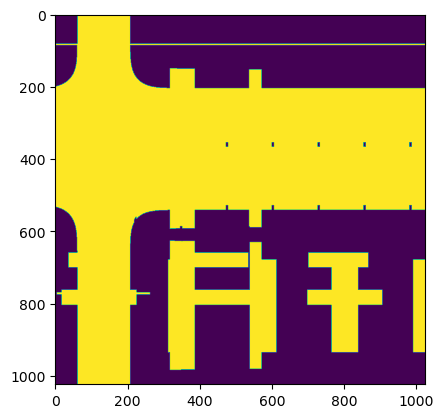

In [8]:
plt.imshow(models_stack[0])

In [11]:
spectrographs = np.expand_dims(spectrographs_stack, axis=1)

In [12]:
models = np.expand_dims(models_stack, axis=1)

In [13]:
models.shape

(64, 1, 1024, 1024)

In [14]:
synthetic_rfi.rfi_antenna_data = spectrographs

In [15]:
synthetic_rfi.flags = models

In [17]:
from samrfi import RFIDataset, RFITraining

In [21]:
rfi_dataset = RFIDataset(synthetic_rfi, dir_path=dir_path)
rfi_dataset.create_dataset(num_patches=400, patch_size=256, apply_stretching=False, custom_flag=True,)


Applying median normalization only to 4096 patches...


100%|██████████| 4096/4096 [00:04<00:00, 902.29it/s]



Applying median normalization only to 4096 patches...


100%|██████████| 4096/4096 [00:04<00:00, 929.18it/s] 


(3980, 256, 256) (3980, 256, 256)


In [22]:
cd /home/gpuhost002/ddeal/RFI-AI/sam2/notebooks

/home/gpuhost002/ddeal/RFI-AI/sam2/notebooks



Training SAM 2 model...


400it [01:04,  6.16it/s]


Epoch 2/26, Loss: 0.1775633592158556


400it [01:05,  6.08it/s]


Epoch 3/26, Loss: 0.17783726692199708


...

400it [01:06,  6.06it/s]


Epoch 26/26, Loss: 0.05754325808622525


400it [01:05,  6.11it/s]


Epoch 27/26, Loss: 0.05756351587624522


<Figure size 640x480 with 0 Axes>

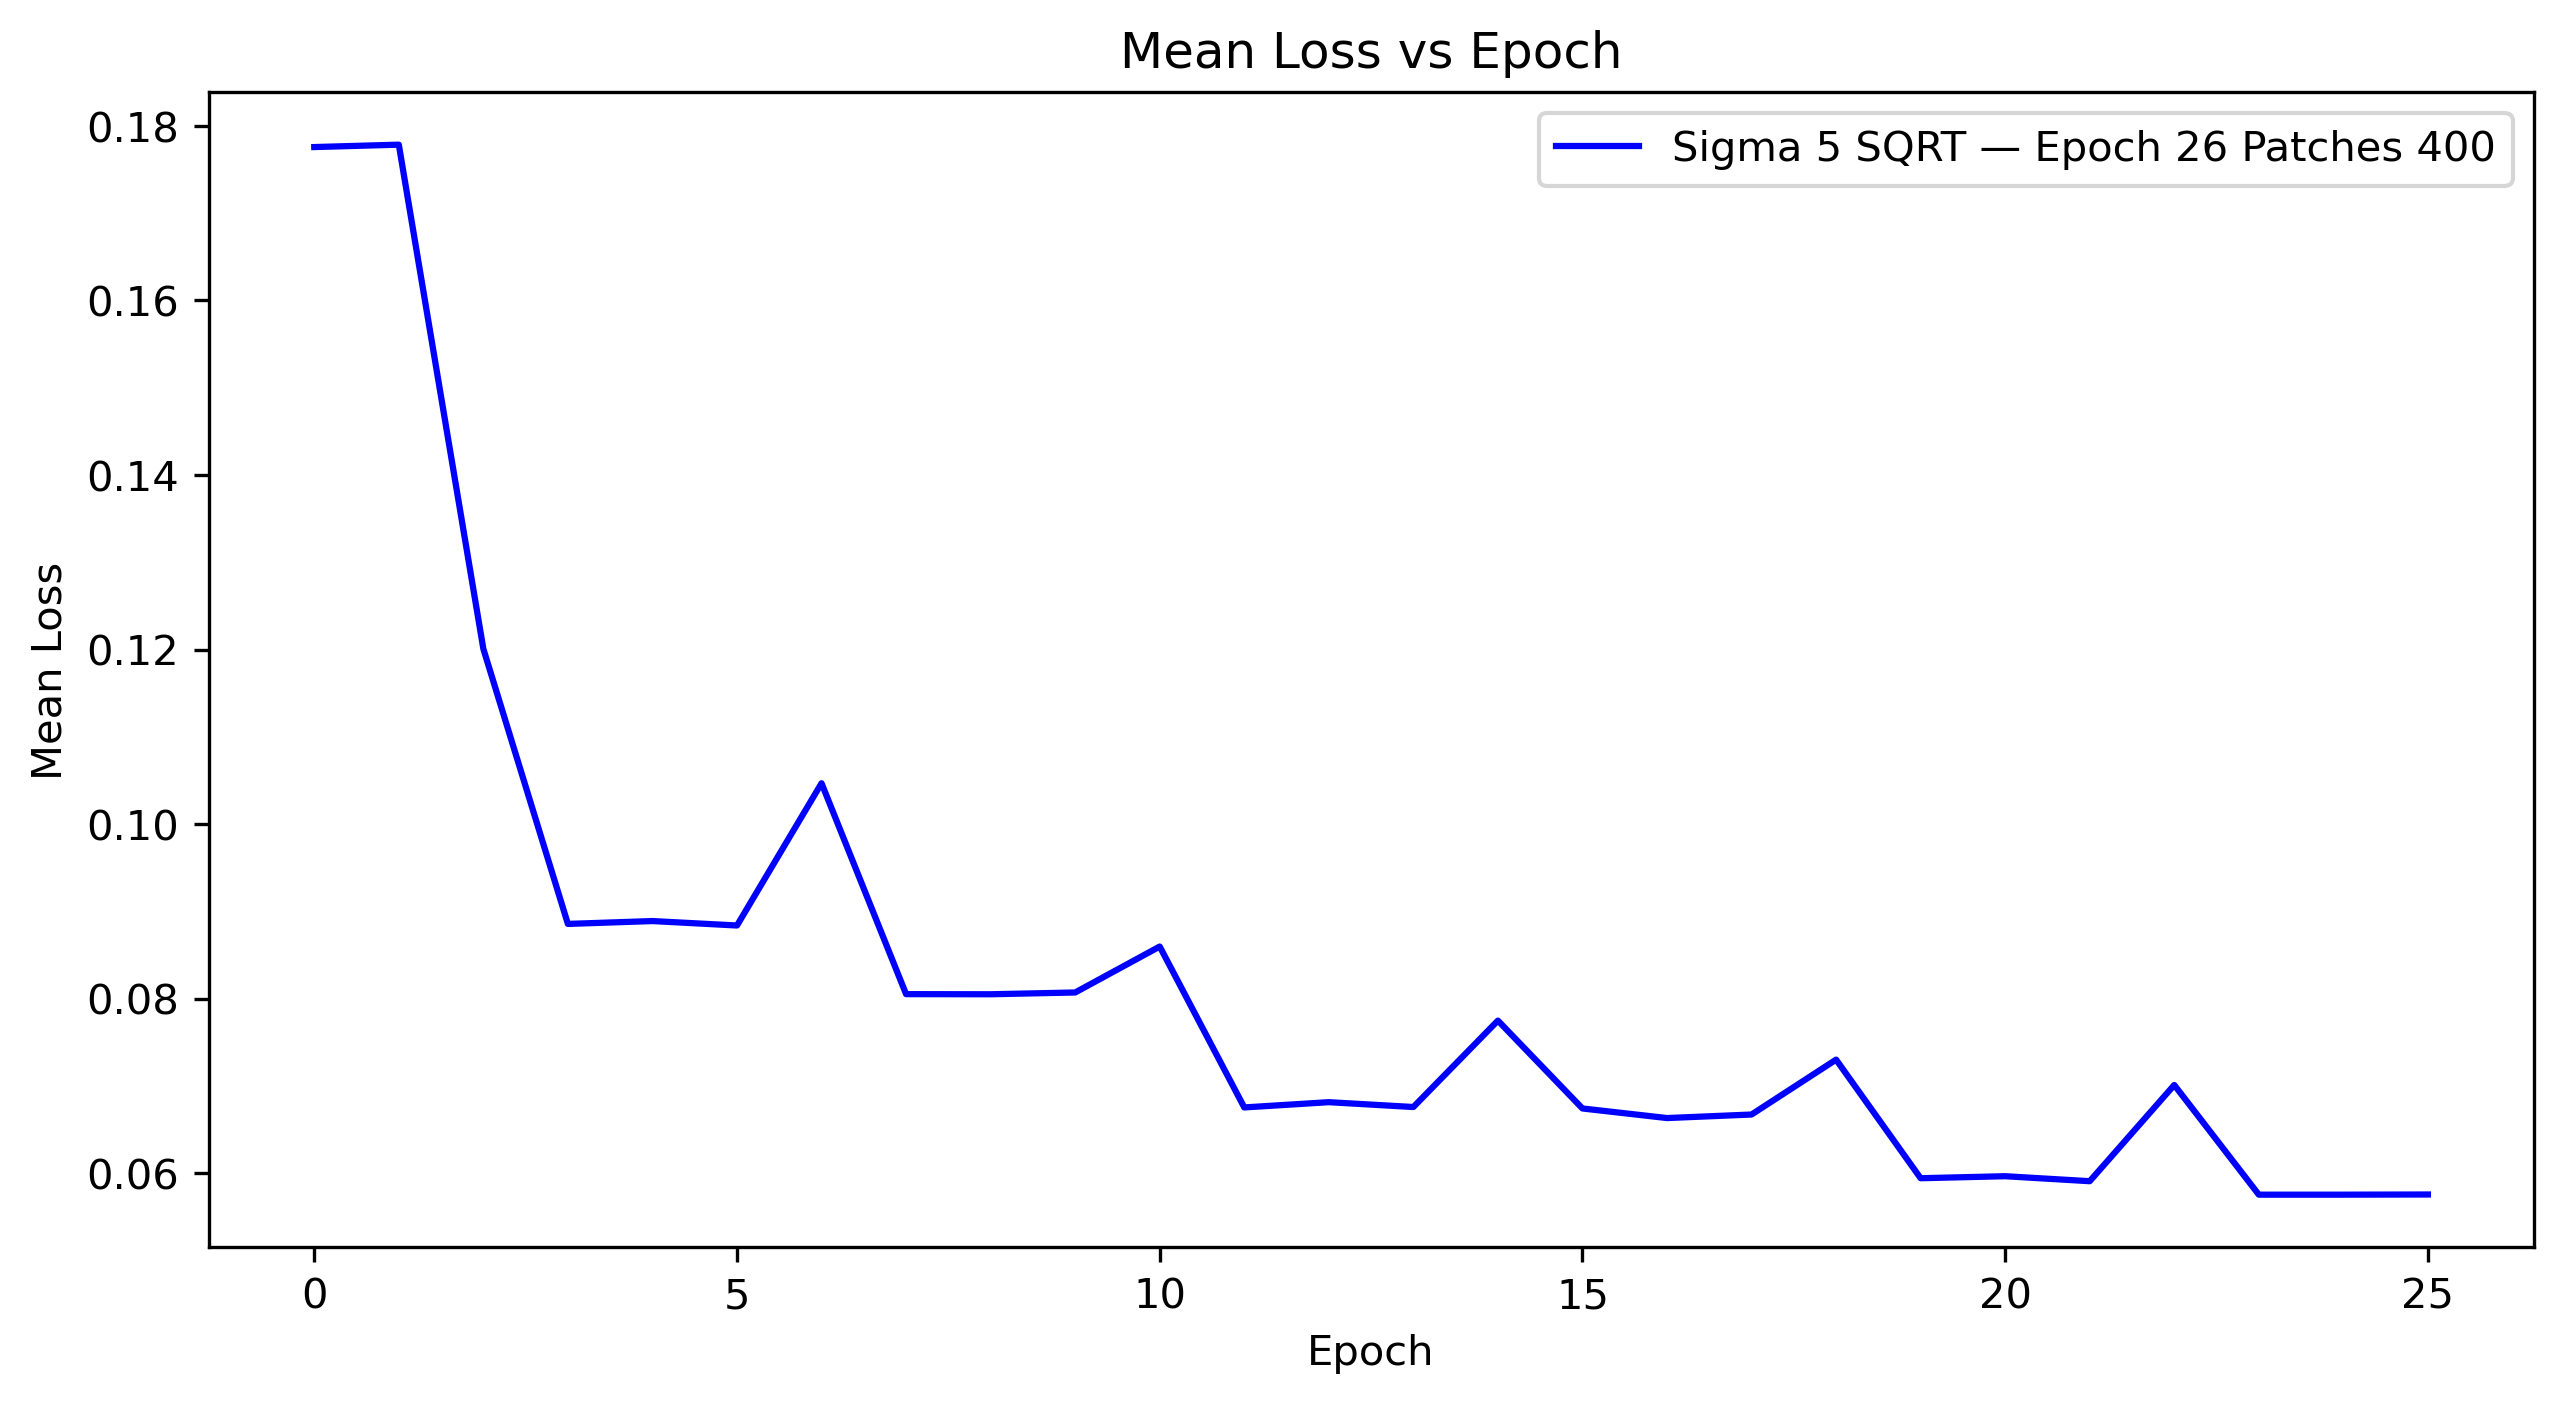

In [23]:
new_model_sam2 = RFITraining(rfi_dataset, device='cuda', dir_path=dir_path)

new_model_sam2.sam2_ckpt = "../checkpoints/sam2.1_hiera_large.pt"
new_model_sam2.sam2_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"
new_model_sam2.train_sam2(num_epochs=26, batch_size=None, step_size=500, num_points=256)